<a href="https://colab.research.google.com/github/Hirakhan15/PCOs/blob/main/test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

ROOT_DIR = '/content/drive/MyDrive/PCOS'
number_of_images = {}

for dir in os.listdir(ROOT_DIR):
   number_of_images[dir] = len(os.listdir(os.path.join(ROOT_DIR,dir)))
   print("",dir,"" ,number_of_images[dir])

 noninfected  5000
 infected  5000


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = []
for category in ['infected', 'noninfected']:
    folder_path = os.path.join(ROOT_DIR, category)
    for img in os.listdir(folder_path):
        data.append({'filepath': os.path.join(folder_path, img), 'label': category})

df = pd.DataFrame(data)

# Splitting 80/10/10
train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input

# Augmentation for Training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only Preprocessing for Val/Test
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_gen = test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

Found 8000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load MobileNet without the top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freezing the base

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x) # More efficient than Flatten for MobileNet
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('pcos_mobilenet.h5', save_best_only=True)
]

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, # Adjusted based on typical PCOS convergence
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8128 - loss: 0.3997

250/250 ━━━━━━━━━━━━━━━━━━━━ 2372s 9s/step - accuracy: 0.8130 - loss: 0.3992 - val_accuracy: 0.9460 - val_loss: 0.1355
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - accuracy: 0.9384 - loss: 0.1568 - val_accuracy: 0.8870 - val_loss: 0.2167
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.9472 - loss: 0.1287 - val_accuracy: 0.9280 - val_loss: 0.1494
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.9527 - loss: 0.1163 - val_accuracy: 0.9140 - val_loss: 0.1714
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.9612 - loss: 0.1070 - val_accuracy: 0.9330 - val_loss: 0.1465
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.9609 - loss: 0.1037 - val_accuracy: 0.9180 - val_loss: 0.1784


In [8]:
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

loss, accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

Found 1000 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 238s 8s/step - accuracy: 0.9453 - loss: 0.1312
Final Test Accuracy: 94.70%


32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


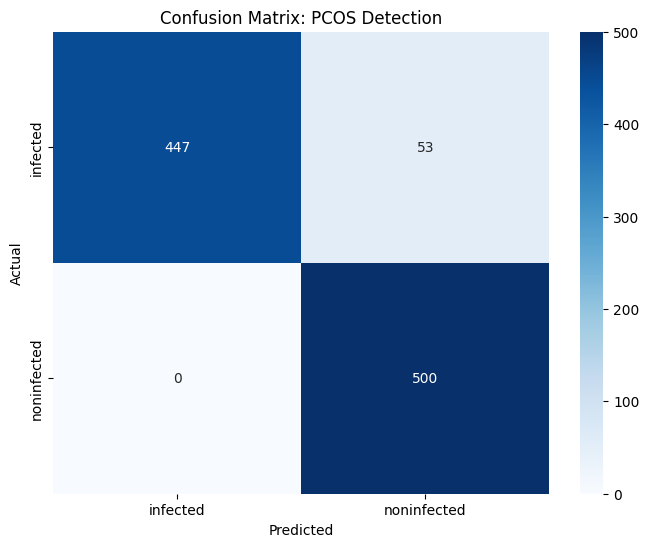


Classification Report:
              precision    recall  f1-score   support

    infected       1.00      0.89      0.94       500
 noninfected       0.90      1.00      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
# Important: shuffle=False in test_gen ensures labels match predictions
test_gen.reset()
predictions = model.predict(test_gen)
pred_labels = (predictions > 0.5).astype(int) # Convert probabilities to 0 or 1

# 2. Get true labels
true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 3. Create Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: PCOS Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 4. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

In [10]:
# Assuming 'cm' is your confusion matrix from the previous step
# In a binary classification (0=Healthy, 1=Infected):
# cm[0,0] = TN, cm[0,1] = FP
# cm[1,0] = FN, cm[1,1] = TP

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Healthy correctly identified): {tn}")
print(f"False Positives (Healthy misidentified as PCOS): {fp}")
print(f"False Negatives (PCOS missed by model): {fn}")
print(f"True Positives (PCOS correctly identified): {tp}")

True Negatives (Healthy correctly identified): 447
False Positives (Healthy misidentified as PCOS): 53
False Negatives (PCOS missed by model): 0
True Positives (PCOS correctly identified): 500
